In [1]:
from data import AttentionPolicy
from state import State, vectorize, tokenize
from data import load_games

In [2]:
%load_ext autoreload
%autoreload 1

In [2]:
import torch
from data import models
import state

model = AttentionPolicy(*models["small"])
# w = torch.load("./model/medium/100k_20.pth", weights_only=True)
w = torch.load("./model/small/100k_5.pth", weights_only=True)
w = {k: v for k, v in w.items() if "mask" not in k}
model.load_state_dict(w, strict=False) # terrible value network!

_IncompatibleKeys(missing_keys=['blocks.0.mask', 'blocks.1.mask'], unexpected_keys=[])

In [3]:
import torch
import math
from state import total_tokens

class AttentionBlock(torch.nn.Module):
    def __init__(self, demb, nth_layer):
        super().__init__()
        self.act = torch.nn.ReLU()
        self.norm = torch.nn.LayerNorm(demb)
        self.qkv = torch.nn.Linear(demb, demb*3)
        self.mlp = torch.nn.Sequential(
            torch.nn.LayerNorm(demb),
            torch.nn.Linear(demb, demb*3),
            torch.nn.ReLU(),
            torch.nn.Linear(demb*3, demb),
        )
        mask = torch.tril(torch.ones(200, 200)).view(1, 200, 200)
        mask[:, :73, :73] = 1 # mask sure they can view all board
        self.register_buffer("mask", mask.bool())
        self.nth_layer = nth_layer
        self.dropout = torch.nn.Dropout(0.25)

    def forward(self, x: torch.Tensor):
        B, T, C = x.shape
        x = self.qkv(self.act(self.norm((start:=x))))
        q, k, v = x.split(C, dim=2)
        attn = q @ k.transpose(-2, -1) * (1 / math.sqrt(C))
        attn = attn.masked_fill(~self.mask[:,:T,:T], float("-inf"))
        attn = torch.softmax(attn, dim=-1)
        out = attn @ v
        x = self.mlp(self.dropout(out))
        return x + start, attn

class AttentionPolicy(torch.nn.Module):
    def __init__(self, embedding, n_layer):
        super().__init__()
        self.total_tokens = total_tokens + 2
        self.emb = torch.nn.Embedding(self.total_tokens, embedding)
        self.blocks = torch.nn.ModuleList([AttentionBlock(embedding, i) for i in range(n_layer)])
        self.norm = torch.nn.LayerNorm(embedding)
        self.linear = torch.nn.Linear(embedding, self.total_tokens)
        self.act = torch.nn.ReLU()
    def forward(self, x, show_attn=False):
        x = self.emb(x)
        attns = []
        for block in self.blocks:
            x, attn = block(x)
            attns.append(attn)
        x = self.act(self.norm(x))
        logits = self.linear(x)
        if show_attn:
            return logits, attns
        return logits

model_size = "medium"
print(models[model_size])
model = AttentionPolicy(*models[model_size])
# w = torch.load("./model/medium/100k_20.pth", weights_only=True)
w = torch.load(f"./model/{model_size}/100k_10.pth", weights_only=True)
w = {k: v for k, v in w.items() if "mask" not in k}
model.load_state_dict(w, strict=False) # terrible value network!

(128, 5)


_IncompatibleKeys(missing_keys=['blocks.0.mask', 'blocks.1.mask', 'blocks.2.mask', 'blocks.3.mask', 'blocks.4.mask'], unexpected_keys=[])

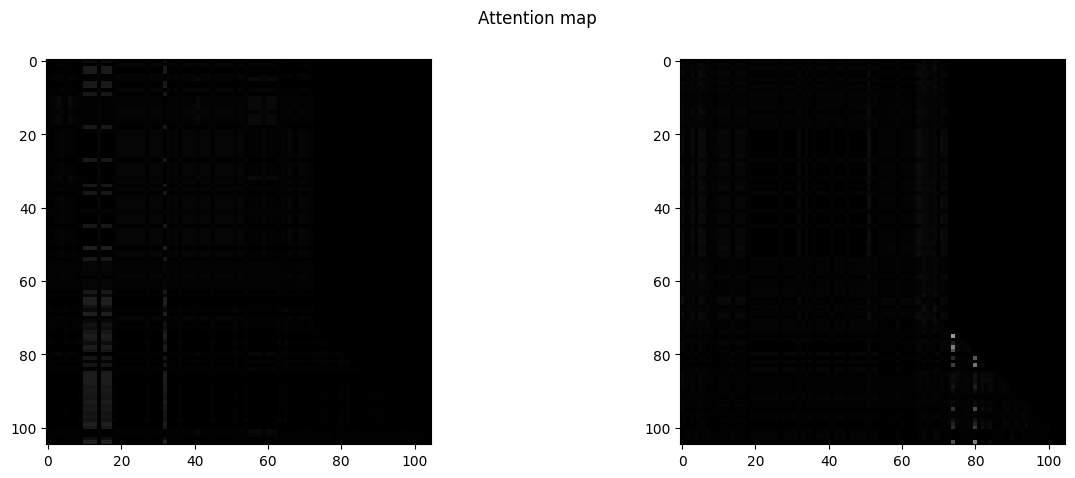

In [5]:
import matplotlib.pyplot as plt
import chess

vector = State.from_fen("rnb1kbnr/pppp1ppp/8/4p1q1/4P3/5N2/PPPP1PPP/RNBQKB1R", chess.WHITE).serialize(prev_action=vectorize("d8g5"))
x = torch.tensor(vector).unsqueeze(0)

_, attns = model(x, show_attn=True)
attns = [attn.squeeze(0).detach().numpy() for attn in attns]

fig, ax = plt.subplots(1,2,figsize=(15, 5))
fig.suptitle("Attention map")
ax[0].imshow(attns[0], vmax=1, vmin=0, cmap="gray")
ax[1].imshow(attns[1], vmax=1, vmin=0, cmap="gray")
fig.savefig("attention_map.png")

In [37]:
import chess
import matplotlib.pyplot as plt
import dtypes
from IPython.display import SVG, display

def anal(fen, turn: chess.Color, prev_action: dtypes.Action=None, return_svg=False, ground_truth=None, fig=True):
    state = State.from_fen(fen, turn)
    x = state.serialize(prev_action=prev_action)
    x = torch.tensor(x).unsqueeze(0)
    prob = model(x).squeeze(0)
    tok = prob.argmax(dim=1).tolist()
    print([tokenize(token) for token in tok[-5:]])
    legal_action = state.get_legel_actions()
    legal_tok_dist = prob[-1].softmax(dim=0)[legal_action]
    sorted_index_legal_tok_dist = torch.argsort(legal_tok_dist, descending=True)
    sorted_legal_action = [legal_action[index] for index in sorted_index_legal_tok_dist]
    top_5_action = sorted_legal_action[:5]
    print(f"Cumprob of legal actions: {legal_tok_dist.sum()}")
    if fig:
        fig, ax = plt.subplots(figsize=(15, 5))
        ax.bar([tokenize(i) for i in sorted_legal_action], legal_tok_dist[sorted_index_legal_tok_dist].tolist())
        ax.set_title(fen)
    colors = ["#0000cccc"]*5
    if prev_action is not None:
        top_5_action.append(prev_action)
        colors.append("#000000")
    svg_arrows = State.svg_arrows(top_5_action, colors)
    if ground_truth is not None:
        svg_arrows.extend(State.svg_arrows([ground_truth], ["#cc0000cc"]))
    print(svg_arrows)
    if return_svg:
        return state.render(svg_arrows)
    else:
        return display(SVG(state.render(svg_arrows)))

['e7e6', 'e7e5', 'e7e5', 'e7e6', 'e7e5']
Cumprob of legal actions: 0.9982258677482605
[Arrow(E7, E5, color='#0000cccc'), Arrow(C7, C5, color='#0000cccc'), Arrow(E7, E6, color='#0000cccc'), Arrow(D7, D5, color='#0000cccc'), Arrow(F7, F5, color='#0000cccc'), Arrow(E2, E4, color='#000000'), Arrow(E7, E5, color='#cc0000cc')]


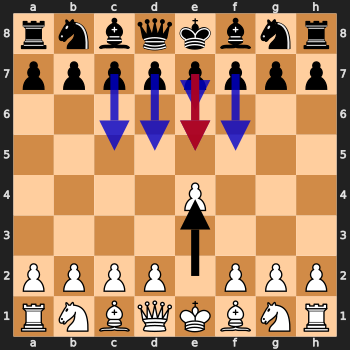

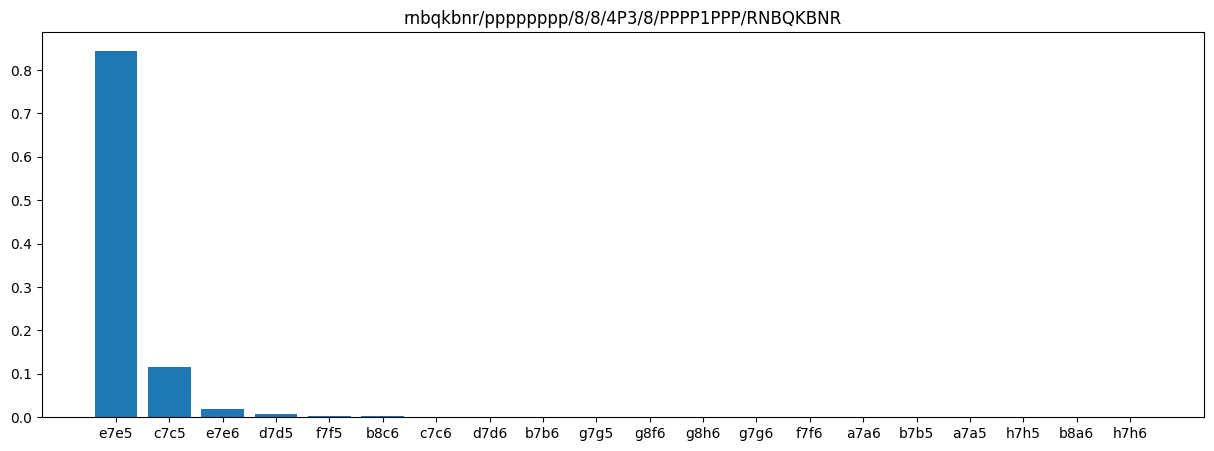

In [38]:
after_e2e4 = "rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR"
anal(after_e2e4, chess.BLACK, vectorize("e2e4"), ground_truth=vectorize("e7e5"))

['b1c3', 'e4d5', 'b1c3', 'c4g8', 'c4g8']
Cumprob of legal actions: 0.875151515007019
[Arrow(C4, G8, color='#0000cccc'), Arrow(B1, C3, color='#0000cccc'), Arrow(F3, E5, color='#0000cccc'), Arrow(D2, D4, color='#0000cccc'), Arrow(D2, D3, color='#0000cccc'), Arrow(F7, F5, color='#000000')]


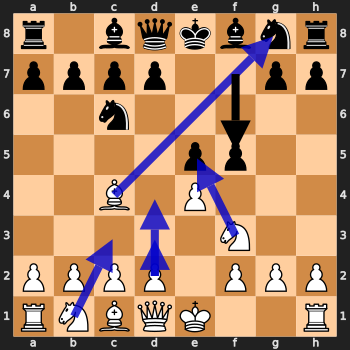

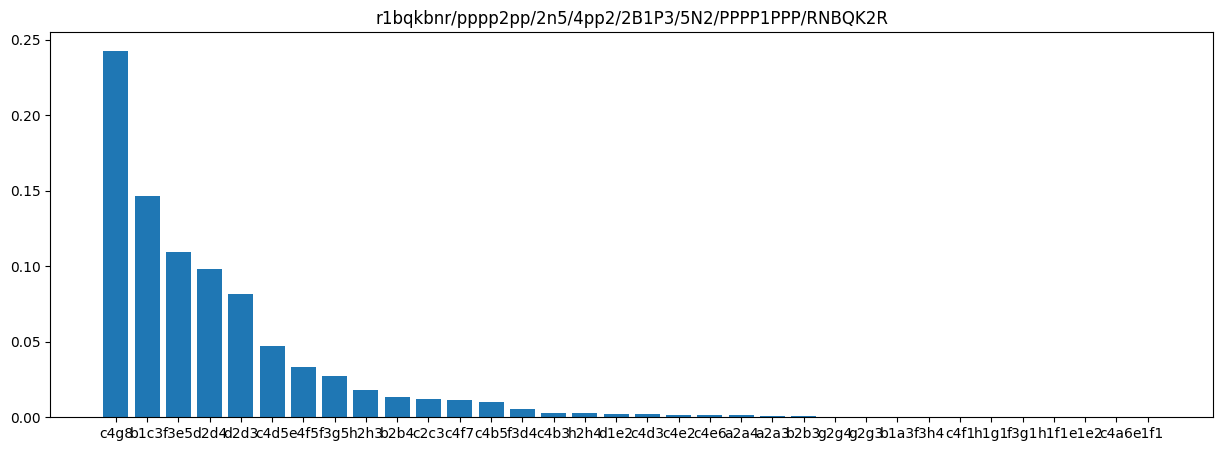

In [39]:
kingside_white_castling_possible = "r1bqkbnr/pppp2pp/2n5/4pp2/2B1P3/5N2/PPPP1PPP/RNBQK2R"
anal(kingside_white_castling_possible, chess.WHITE, vectorize("f7f5"))

['d2d4', 'f1c4', 'd2d4', 'd2d4', 'f1c4']
Cumprob of legal actions: 0.9956427812576294
[Arrow(F1, C4, color='#0000cccc'), Arrow(D2, D4, color='#0000cccc'), Arrow(C2, C3, color='#0000cccc'), Arrow(F1, B5, color='#0000cccc'), Arrow(B1, C3, color='#0000cccc'), Arrow(D8, G5, color='#000000')]


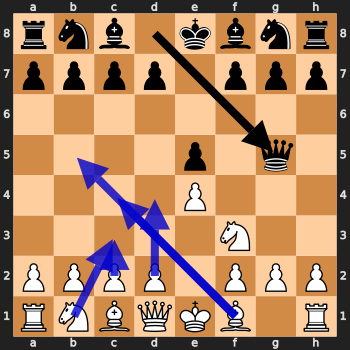

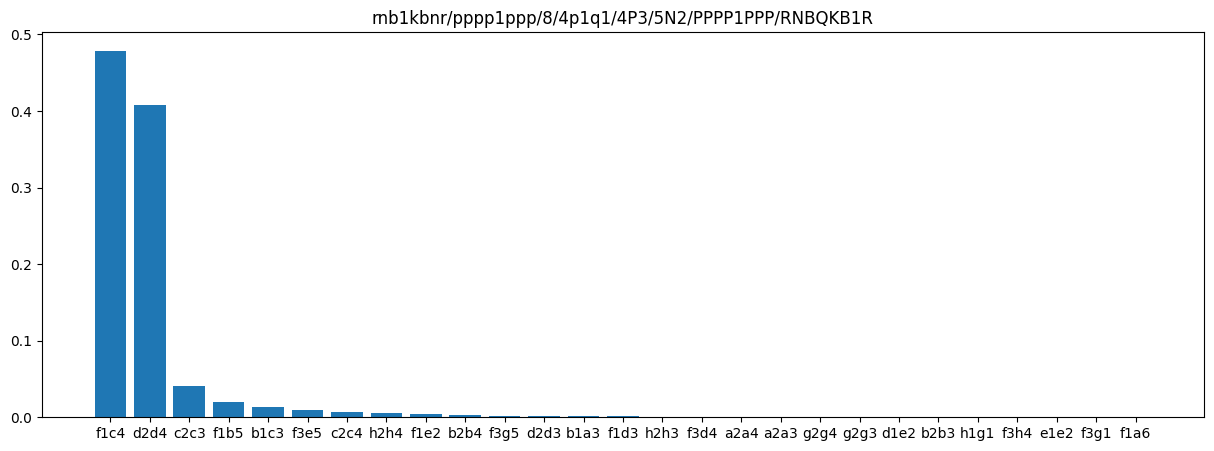

In [40]:
anal("rnb1kbnr/pppp1ppp/8/4p1q1/4P3/5N2/PPPP1PPP/RNBQKB1R", chess.WHITE, vectorize("d8g5"))

['c6d4', 'c6b4', 'c6d4', 'c6e7', 'g8f6']
Cumprob of legal actions: 0.9688946008682251
[Arrow(G8, F6, color='#0000cccc'), Arrow(F8, C5, color='#0000cccc'), Arrow(G8, E7, color='#0000cccc'), Arrow(D7, D6, color='#0000cccc'), Arrow(D8, F6, color='#0000cccc')]


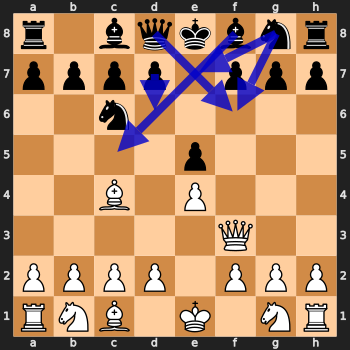

['c6d4', 'c6b4', 'c6e7', 'c6e7', 'f8c5']
Cumprob of legal actions: 0.9890227317810059
[Arrow(F8, C5, color='#0000cccc'), Arrow(D8, F6, color='#0000cccc'), Arrow(G8, F6, color='#0000cccc'), Arrow(D8, E7, color='#0000cccc'), Arrow(F8, B4, color='#0000cccc'), Arrow(D1, F3, color='#000000')]


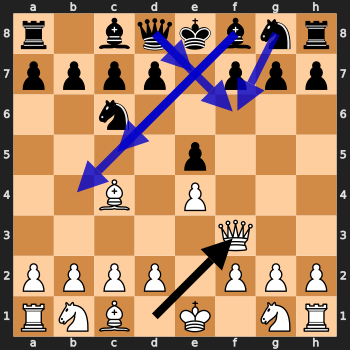

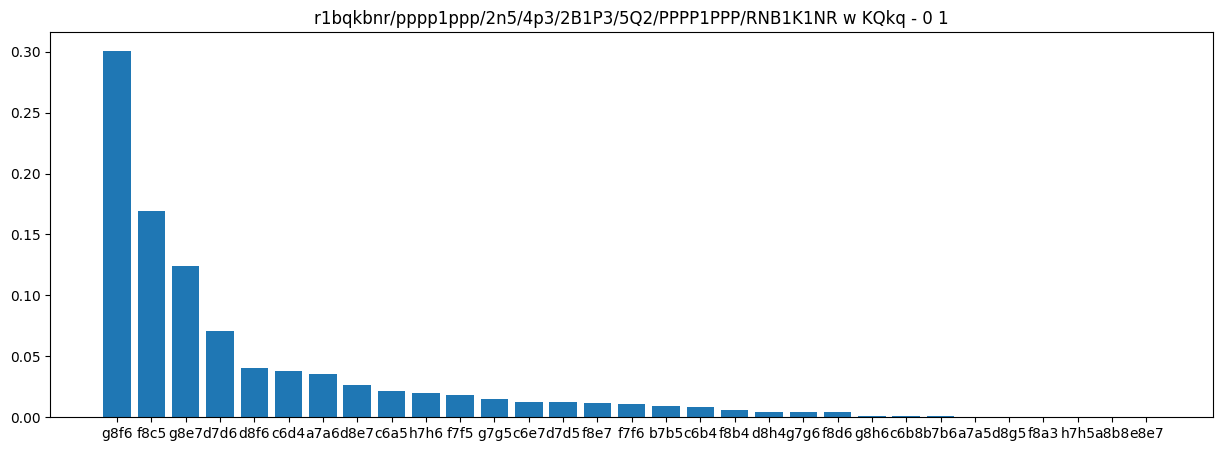

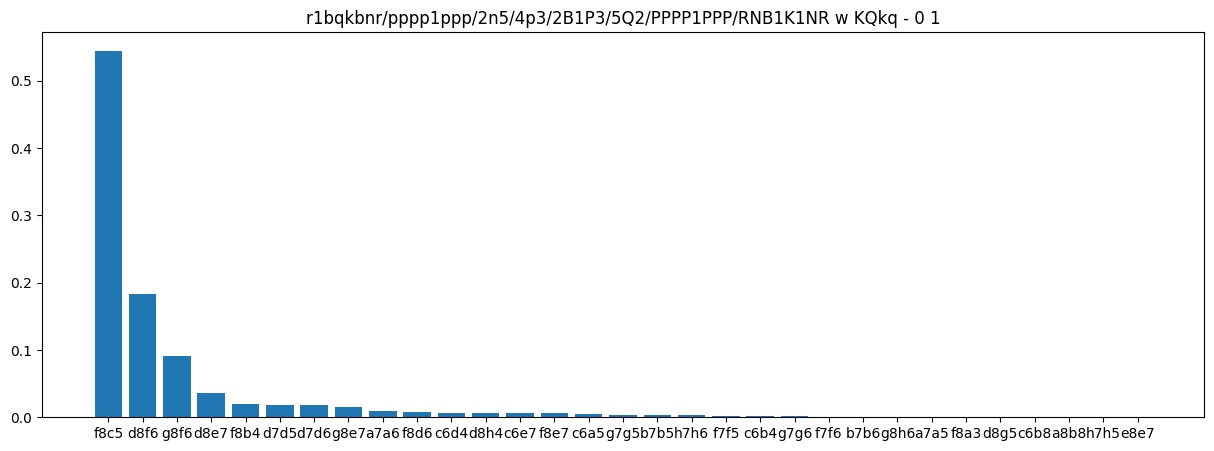

In [55]:
anal("r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPP1PPP/RNB1K1NR w KQkq - 0 1", chess.BLACK)
anal("r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPP1PPP/RNB1K1NR w KQkq - 0 1", chess.BLACK, vectorize("d1f3"))

In [14]:
(board:=chess.Board()).set_fen("r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPPNPPP/RNB1K2R b KQkq - 1 1")

board.has_kingside_castling_rights(chess.WHITE)
board.has_kingside_castling_rights(chess.BLACK)

True

In [19]:
from functools import cache

@cache
def load(save_path=None):
    path = "./data/DATABASE4U.pgn"
    mode = "sequence" # or cnn
    vectors, actions, attention_masks,results = load_games(path, mode, max_length=160, save_path=save_path)

    vectors, results = vectors[:100], results[:100]
    return vectors, results

In [20]:
vectors, results = load(save_path=f"./data/processed/database4u_withturn_sequence.npz")

--- Loaded cache from ./data/processed/database4u_withturn_sequence.npz ---


In [12]:
svgs = []

for i in range(100):
    print((deserialized:=State.deserialize((vector:=vectors[i]), mode="sequence")))
    fen = deserialized.split("<legal_moves>")[0]
    action = vector[vector.tolist().index(vectorize("<me>"))+2]
    prev_action = None
    if (op:=vectorize("<opponent>")) in vector:
        prev_action = vector[vector.tolist().index(op)+1]
    svg = anal(fen, i%2==0, prev_action, return_svg=True, ground_truth=action, fig=False)
    svgs.append(svg)

rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR<legal_moves>g1h3g1f3b1c3b1a3h2h3g2g3f2f3e2e3d2d3c2c3b2b3a2a3h2h4g2g4f2f4e2e4d2d4c2c4b2b4a2a4<white_king><white_queen><black_king><black_queen><me><white_turn>e2e4<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
['g7g6', 'g7g6', 'c8d7', 'e7e6', 'e2e4']
Cumprob of legal actions: 0.9989861845970154
[Arrow(E2, E4, color='#0000cccc'), Arrow(D2, D4, color='#0000cccc'), Arrow(F2, F4, color='#0000cccc'), Arrow(C2, C4, color='#0000cccc'), Arrow(B1, C3, color='#0000cccc'), Arrow(E2, E4, color='#cc0000cc')]
rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR<legal_moves>g8h6g8f6b8c6b8a6h7h6g7g6f7f6e7e6d7d6c7c6b7b6a7a6h7h5g7g5f7f5e7e5d7d5c7c5b7b5a7a5<white_king><white_queen><black_king><black_queen><opponent>e2e4<me><

In [13]:
from IPython.display import display, HTML
import ipywidgets as widgets

def show_svgs(svgs):
    # Create next and previous buttons
    prev_button = widgets.Button(description='Previous')
    next_button = widgets.Button(description='Next')

    # Create an output widget to display the SVG
    output = widgets.Output()

    # Keep track of current position
    current_position = 0

    # Define functions to update the display when buttons are clicked
    def show_position(position):
        global current_position
        current_position = position
        with output:
            output.clear_output(wait=True)
            display(HTML(svgs[current_position]))
            
    def on_prev_button_clicked(b):
        global current_position
        if current_position > 0:
            show_position(current_position - 1)
            
    def on_next_button_clicked(b):
        global current_position
        if current_position < len(svgs) - 1:
            show_position(current_position + 1)

    # Connect the functions to the buttons
    prev_button.on_click(on_prev_button_clicked)
    next_button.on_click(on_next_button_clicked)

    # Display the initial SVG
    show_position(0)

    # Display the buttons and output widgets
    display(widgets.HBox([prev_button, next_button]))
    display(output)

In [14]:
show_svgs(svgs)

Output()

In [17]:
from agent import *
state: State = State()
agent = TorchPolicyAgent(model, state, temperature=0.01)

svgs = []
i = 0
prev_action = None
while i<100:
    print(i)
    svg = anal(state.board.board_fen(), i%2==0, prev_action, return_svg=True, fig=False)
    uci_move = agent.respond()
    svgs.append(svg)
    prev_action = vectorize(uci_move)
    if state.game_over():
        break
    i += 1

0
['g7g6', 'g7g6', 'c8d7', 'e7e6', 'e2e4']
Cumprob of legal actions: 0.9989861845970154
[Arrow(E2, E4, color='#0000cccc'), Arrow(D2, D4, color='#0000cccc'), Arrow(F2, F4, color='#0000cccc'), Arrow(C2, C4, color='#0000cccc'), Arrow(B1, C3, color='#0000cccc')]
tensor(nan, grad_fn=<SumBackward0>)
[('g1h3', 1.0), ('g1f3', 0.0), ('b1c3', 0.0), ('b1a3', 0.0), ('h2h3', 0.0)]
796
1
['b8c6', 'd7d5', 'e7e5', 'e7e6', 'e7e5']
Cumprob of legal actions: 0.9988541007041931
[Arrow(E7, E5, color='#0000cccc'), Arrow(C7, C5, color='#0000cccc'), Arrow(E7, E6, color='#0000cccc'), Arrow(D7, D5, color='#0000cccc'), Arrow(B7, B6, color='#0000cccc'), Arrow(E2, E4, color='#000000')]
tensor(nan, grad_fn=<SumBackward0>)
[('g8h6', 1.0), ('g8f6', 0.0), ('b8c6', 0.0), ('b8a6', 0.0), ('h7h6', 0.0)]
3364
2
['c8d7', 'd2d4', 'd2d4', 'b8c6', 'g1f3']
Cumprob of legal actions: 0.9995155334472656
[Arrow(G1, F3, color='#0000cccc'), Arrow(F2, F4, color='#0000cccc'), Arrow(F1, C4, color='#0000cccc'), Arrow(D2, D4, color='#0000

In [18]:
show_svgs(svgs)

Output()

In [37]:
state: State = State.from_fen("rnbqkbnr/pppp1ppp/8/4p3/4PP2/8/PPPP2PP/RNBQKBNR w KQkq - 0 1", chess.BLACK)

x = state.serialize(prev_action=vectorize("f2f4"))
print(State.deserialize(x))
x = torch.tensor(x).unsqueeze(0)
prob = model(x).squeeze(0)[-1]
values, indices =torch.topk(prob, 5, dim=0)
print(tokenize(indices[torch.multinomial(values.softmax(dim=0), 1)].item()))
# indices == torch.argsort(prob, descending=True)[:5]

rnbqkbnr/pppp1ppp/8/4p3/4PP2/8/PPPP2PP/RNBQKBNR<legal_moves>g8e7g8h6g8f6f8e7f8d6f8c5f8b4f8a3e8e7d8e7d8f6d8g5d8h4b8c6b8a6e5f4h7h6g7g6f7f6d7d6c7c6b7b6a7a6h7h5g7g5f7f5d7d5c7c5b7b5a7a5<white_king><white_queen><black_king><black_queen><opponent>f2f4<me><black_turn>
f8c5


In [36]:
[tokenize(act) for act in indices.tolist()]

['g7g5', 'f8c5', 'e5f4', 'd7d5', 'g8f6']